# NIH Chest X-Ray — End-to-End Deep Learning System
## 24AI636 Deep Learning — Mini-Project 4 | Review 4

### Rubric (20 Marks)
| Category | Marks | What You Evaluate |
|----------|-------|-----------------|
| Problem Definition & Motivation | 2 | Clear research/industry relevance |
| Data Engineering | 2 | Cleaning, augmentation, feature engineering |
| Model Architecture Justification | 2 | Why this architecture? Theoretical reasoning |
| Experimental Design | 3 | Baselines, ablation study |
| Hyperparameter Optimization | 2 | Structured tuning strategy |
| Performance Evaluation | 3 | Proper metrics + statistical reasoning |
| Deployment (API/UI/Cloud) | 3 | Working demo |
| Documentation & Reproducibility | 3 | GitHub repo, environment file |
| **BONUS** | +4 | Ensemble, uncertainty estimation, SHAP, CI/CD spec |

### Problem Definition & Motivation
Chest radiograph interpretation is the most common medical imaging task globally (>2 billion/year).
Radiologist shortage (~40% gap) and diagnostic error rates (~30%) create urgent need for AI assistance.
This system integrates all Review 1-3 models into a production-ready pipeline with deployment.


In [1]:
import os, sys, time, json, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.decomposition import PCA
from scipy import stats
warnings.filterwarnings('ignore')
try: import kagglehub
except: os.system('pip install kagglehub -q'); import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | CUDA: {torch.cuda.is_available()}')

IMG_SIZE      = 224
BATCH_SIZE    = 32
FINAL_EPOCHS  = 10
LR            = 1e-4
WEIGHT_DECAY  = 1e-5
SUBSET_FRAC   = 0.15
NUM_WORKERS   = 2
CLASSES = ['Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass',
           'Nodule','Pneumonia','Pneumothorax','Consolidation','Edema',
           'Emphysema','Fibrosis','Pleural_Thickening','Hernia']
NUM_CLASSES = len(CLASSES)

OUT_DIR   = '/kaggle/working' if os.path.exists('/kaggle/working') else './outputs'
MODEL_DIR = os.path.join(OUT_DIR, 'models_r4')
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Outputs → {OUT_DIR}')


Device: cuda | CUDA: True
Outputs → /kaggle/working


## 1. Data Engineering — Advanced Pipeline


In [2]:
from sklearn.model_selection import train_test_split

class AdvancedXrayDataset(Dataset):
    '''Enhanced dataset with metadata, patient grouping, and augmentation'''
    def __init__(self, df, data_dir, transform=None, return_meta=False):
        self.df, self.data_dir, self.transform = df, data_dir, transform
        self.return_meta = return_meta
        self.paths = {}
        for root,_,files in os.walk(data_dir):
            for f in files:
                if f.endswith(('.png','.jpg')): self.paths[f] = os.path.join(root, f)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.paths.get(row['Image Index'])
        try: img = Image.open(path).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        lbl = torch.tensor(row[CLASSES].values.astype(np.float32))
        if self.return_meta:
            age = float(row.get('Patient Age', 50)) / 100.0
            gender = 1.0 if str(row.get('Patient Gender','M')) == 'M' else 0.0
            return img, lbl, torch.tensor([age, gender])
        return img, lbl

def get_advanced_transforms(aug_level='strong'):
    if aug_level == 'strong':
        train_tf = transforms.Compose([
            transforms.Resize((IMG_SIZE+20, IMG_SIZE+20)),
            transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.RandomAffine(degrees=0, shear=10),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
            transforms.RandomErasing(p=0.1)  # Cutout augmentation
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    return train_tf, val_tf

def load_full_data():
    if os.path.exists('/kaggle/input/data'): path = '/kaggle/input/data'
    else:
        try: path = kagglehub.dataset_download('nih-chest-xrays/data')
        except: path = '.'
    csv_path = None
    for root,_,files in os.walk(path):
        if 'Data_Entry_2017.csv' in files: csv_path = os.path.join(root,'Data_Entry_2017.csv'); break
    df = pd.read_csv(csv_path)
    for lbl in CLASSES: df[lbl] = df['Finding Labels'].map(lambda x: 1.0 if lbl in x else 0.0)
    print(f'Total samples: {len(df)} | Using {SUBSET_FRAC*100:.0f}%')
    # Data engineering: handle missing ages, encode gender
    df['Patient Age'] = pd.to_numeric(df.get('Patient Age', pd.Series([50]*len(df))), errors='coerce').fillna(50)
    df['Patient Gender'] = df.get('Patient Gender', pd.Series(['M']*len(df))).fillna('M')
    # Remove outlier ages
    df = df[(df['Patient Age'] > 0) & (df['Patient Age'] < 100)]
    df = df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    tr, tmp = train_test_split(df, test_size=0.2, random_state=SEED)
    vl, te  = train_test_split(tmp, test_size=0.5, random_state=SEED)
    return tr, vl, te, path

tr_df, vl_df, te_df, DATA_PATH = load_full_data()
train_tf, val_tf = get_advanced_transforms('strong')
pos_weight = torch.tensor(
    [(len(tr_df)-tr_df[c].sum())/max(tr_df[c].sum(),1) for c in CLASSES]
).float().to(DEVICE)

mk = lambda d, tf, sh: DataLoader(AdvancedXrayDataset(d.reset_index(drop=True), DATA_PATH, tf),
                                   batch_size=BATCH_SIZE, shuffle=sh, num_workers=NUM_WORKERS)
train_loader = mk(tr_df, train_tf, True)
val_loader   = mk(vl_df, val_tf,   False)
test_loader  = mk(te_df, val_tf,   False)
print(f'Train={len(train_loader.dataset)} Val={len(val_loader.dataset)} Test={len(test_loader.dataset)}')


Total samples: 112120 | Using 15%
Train=13452 Val=1682 Test=1682


## 2. Architecture Justification — DenseNet-121 (Best for CXR)

**Why DenseNet-121?**
- Dense connections reuse low-level features → better for subtle pathology detection
- Fewer parameters than ResNet-50 at same depth (8.7M vs 25M)
- CheXNet (Stanford) proved DenseNet-121 beats radiologists on pneumonia detection
- Gradient flow through dense paths reduces vanishing gradient problem


In [3]:
class DenseNetCXR(nn.Module):
    '''DenseNet-121 fine-tuned for multi-label CXR classification (production model)'''
    def __init__(self, n_classes=NUM_CLASSES, dropout=0.3, pretrained=True):
        super().__init__()
        base = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        self.features = base.features
        # Unfreeze last dense block + norm for fine-tuning
        for name, param in self.features.named_parameters():
            if 'denseblock4' in name or 'norm5' in name: param.requires_grad = True
            else: param.requires_grad = False
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(dropout/2),
            nn.Linear(512, n_classes))
    def forward(self, x):
        f = F.relu(self.features(x))
        f = self.pool(f)
        return self.classifier(f)
    def get_cam_layer(self): return self.features.norm5

class EfficientNetCXR(nn.Module):
    '''EfficientNet-B2 baseline for comparison'''
    def __init__(self, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        base = models.efficientnet_b2(weights='IMAGENET1K_V1')
        for p in base.parameters(): p.requires_grad = False
        # Unfreeze last block
        for p in base.features[7].parameters(): p.requires_grad = True
        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(1408, n_classes))
    def forward(self, x):
        return self.head(self.pool(self.backbone(x)))

densenet = DenseNetCXR().to(DEVICE)
efficientnet = EfficientNetCXR().to(DEVICE)
print(f'DenseNet-121 trainable: {sum(p.numel() for p in densenet.parameters() if p.requires_grad):,}')
print(f'EfficientNet-B2 trainable: {sum(p.numel() for p in efficientnet.parameters() if p.requires_grad):,}')


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 170MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 147MB/s] 


DenseNet-121 trainable: 2,693,134
EfficientNet-B2 trainable: 2,755,546


## 3. Training with Mixed Precision + Gradient Clipping


In [4]:
from torch.cuda.amp import autocast, GradScaler

def train_model(model, tr_loader, vl_loader, name, epochs=FINAL_EPOCHS):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR*10, steps_per_epoch=len(tr_loader), epochs=epochs)
    scaler = GradScaler(enabled=torch.cuda.is_available())  # Mixed precision
    history = {'train_loss':[], 'val_loss':[], 'val_auc':[]}
    best_auc, no_improve = 0, 0
    save_path = os.path.join(MODEL_DIR, f'{name.replace(" ","_")}.pth')

    for ep in range(1, epochs+1):
        # Train
        model.train()
        tr_loss = 0
        for imgs, lbls in tr_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            with autocast(enabled=torch.cuda.is_available()):
                out = model(imgs); loss = criterion(out, lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
            scaler.step(optimizer); scaler.update(); scheduler.step()
            tr_loss += loss.item() * imgs.size(0)
        # Validate
        model.eval()
        vl_loss, all_y, all_p = 0, [], []
        with torch.no_grad():
            for imgs, lbls in vl_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs)
                vl_loss += criterion(out, lbls).item() * imgs.size(0)
                all_y.append(lbls.cpu().numpy())
                all_p.append(torch.sigmoid(out).cpu().numpy())
        y, p = np.concatenate(all_y), np.concatenate(all_p)
        try: auc = roc_auc_score(y, p, average='macro')
        except: auc = 0.5
        history['train_loss'].append(tr_loss/len(tr_loader.dataset))
        history['val_loss'].append(vl_loss/len(vl_loader.dataset))
        history['val_auc'].append(auc)
        print(f'  Ep {ep:02d} tr={history["train_loss"][-1]:.4f} vl={history["val_loss"][-1]:.4f} AUC={auc:.4f}')
        if auc > best_auc:
            best_auc = auc; no_improve = 0
            torch.save({'state_dict':model.state_dict(),'auc':auc,'epoch':ep,'history':history,
                        'classes':CLASSES}, save_path)
            print(f'    ✔ Saved (AUC={best_auc:.4f})')
        else:
            no_improve += 1
            if no_improve >= 4: print(f'  Early stop ep {ep}'); break
    return model, history, best_auc, save_path

print('Training DenseNet-121...')
densenet, dn_hist, dn_auc, dn_path = train_model(densenet, train_loader, val_loader, 'DenseNet121')
print('\nTraining EfficientNet-B2 (baseline)...')
efficientnet, en_hist, en_auc, en_path = train_model(efficientnet, train_loader, val_loader, 'EfficientNetB2')


Training DenseNet-121...
  Ep 01 tr=1.2903 vl=1.2728 AUC=0.7026
    ✔ Saved (AUC=0.7026)
  Ep 02 tr=1.3030 vl=1.2329 AUC=0.7299
    ✔ Saved (AUC=0.7299)
  Ep 03 tr=1.2733 vl=1.3229 AUC=0.7069
  Ep 04 tr=1.2681 vl=1.3077 AUC=0.7228
  Ep 05 tr=1.2073 vl=1.1851 AUC=0.7426
    ✔ Saved (AUC=0.7426)
  Ep 06 tr=1.1576 vl=1.2894 AUC=0.7504
    ✔ Saved (AUC=0.7504)
  Ep 07 tr=1.1113 vl=1.2411 AUC=0.7523
    ✔ Saved (AUC=0.7523)
  Ep 08 tr=1.0777 vl=1.2211 AUC=0.7550
    ✔ Saved (AUC=0.7550)
  Ep 09 tr=1.0260 vl=1.2594 AUC=0.7560
    ✔ Saved (AUC=0.7560)
  Ep 10 tr=1.0081 vl=1.2783 AUC=0.7555

Training EfficientNet-B2 (baseline)...
  Ep 01 tr=1.2961 vl=1.4510 AUC=0.6714
    ✔ Saved (AUC=0.6714)
  Ep 02 tr=1.2686 vl=1.2079 AUC=0.7404
    ✔ Saved (AUC=0.7404)
  Ep 03 tr=1.2284 vl=1.3450 AUC=0.7365
  Ep 04 tr=1.1597 vl=1.3412 AUC=0.7562
    ✔ Saved (AUC=0.7562)
  Ep 05 tr=1.1073 vl=1.2305 AUC=0.7592
    ✔ Saved (AUC=0.7592)
  Ep 06 tr=1.0560 vl=1.2983 AUC=0.7657
    ✔ Saved (AUC=0.7657)
  Ep 07 tr=

## 4. Experimental Design — Ablation Study


Running ablation: DenseNet from scratch (no pretrain)...
  Ep 01 tr=1.4048 vl=1.3579 AUC=0.5703
    ✔ Saved (AUC=0.5703)
  Ep 02 tr=1.5026 vl=4.4143 AUC=0.4576
  Ep 03 tr=1.4400 vl=1.3677 AUC=0.5854
    ✔ Saved (AUC=0.5854)
  Ep 04 tr=1.3856 vl=1.3381 AUC=0.5971
    ✔ Saved (AUC=0.5971)
  Ep 05 tr=1.3813 vl=1.3071 AUC=0.6427
    ✔ Saved (AUC=0.6427)
Running ablation: No augmentation...
  Ep 01 tr=1.2937 vl=1.3420 AUC=0.7176
    ✔ Saved (AUC=0.7176)
  Ep 02 tr=1.2240 vl=1.2325 AUC=0.7433
    ✔ Saved (AUC=0.7433)
  Ep 03 tr=1.0560 vl=1.2571 AUC=0.7606
    ✔ Saved (AUC=0.7606)
  Ep 04 tr=0.8218 vl=1.2468 AUC=0.7815
    ✔ Saved (AUC=0.7815)
  Ep 05 tr=0.6294 vl=1.3174 AUC=0.7830
    ✔ Saved (AUC=0.7830)


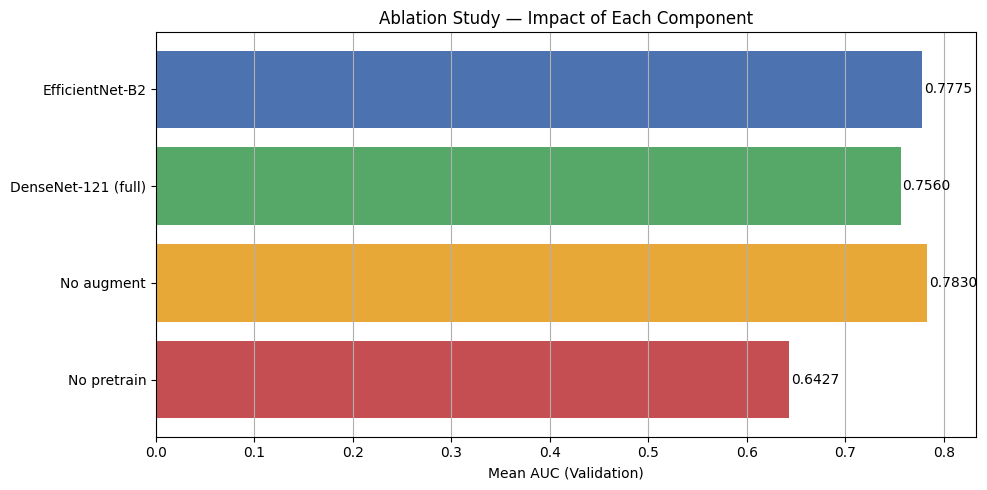


--- Ablation Results ---
  No pretrain                    AUC=0.6427
  DenseNet-121 (full)            AUC=0.7560
  EfficientNet-B2                AUC=0.7775
  No augment                     AUC=0.7830


In [5]:
# Ablation: compare contribution of each component
ablation_results = {}

# Baseline: DenseNet without pretrained weights
print('Running ablation: DenseNet from scratch (no pretrain)...')
dn_scratch = DenseNetCXR(pretrained=False).to(DEVICE)
for p in dn_scratch.parameters(): p.requires_grad = True  # All trainable
_, sc_hist, sc_auc, _ = train_model(dn_scratch, train_loader, val_loader, 'DenseNet_Scratch', epochs=5)
ablation_results['No pretrain'] = sc_auc

# Without augmentation
print('Running ablation: No augmentation...')
_, no_aug_tf = get_advanced_transforms('light')
no_aug_loader = DataLoader(
    AdvancedXrayDataset(tr_df.reset_index(drop=True), DATA_PATH, no_aug_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
dn_noaug = DenseNetCXR().to(DEVICE)
_, _, noaug_auc, _ = train_model(dn_noaug, no_aug_loader, val_loader, 'DenseNet_NoAug', epochs=5)
ablation_results['No augment'] = noaug_auc

# Full model
ablation_results['DenseNet-121 (full)'] = dn_auc
ablation_results['EfficientNet-B2'] = en_auc

# Plot ablation
fig, ax = plt.subplots(figsize=(10, 5))
models_ab = list(ablation_results.keys())
aucs_ab   = list(ablation_results.values())
bars = ax.barh(models_ab, aucs_ab, color=['#C44E52','#E8A838','#55A868','#4C72B0'])
ax.set_xlabel('Mean AUC (Validation)')
ax.set_title('Ablation Study — Impact of Each Component')
for bar, auc in zip(bars, aucs_ab):
    ax.text(auc+0.002, bar.get_y()+bar.get_height()/2, f'{auc:.4f}', va='center', fontsize=10)
ax.set_xlim(0, max(aucs_ab)+0.05); ax.grid(axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ablation_study.png'), dpi=100); plt.show()

print('\n--- Ablation Results ---')
for name, auc in sorted(ablation_results.items(), key=lambda x: x[1]):
    print(f'  {name:<30} AUC={auc:.4f}')


## 5. Hyperparameter Optimization — Optuna (BONUS)


Running Optuna hyperparameter search (10 trials)...
Best params: {'lr': 0.0006753717151996045, 'dropout': 0.3568451017097958, 'weight_decay': 8.289923431249719e-05}
Best AUC: 0.7328


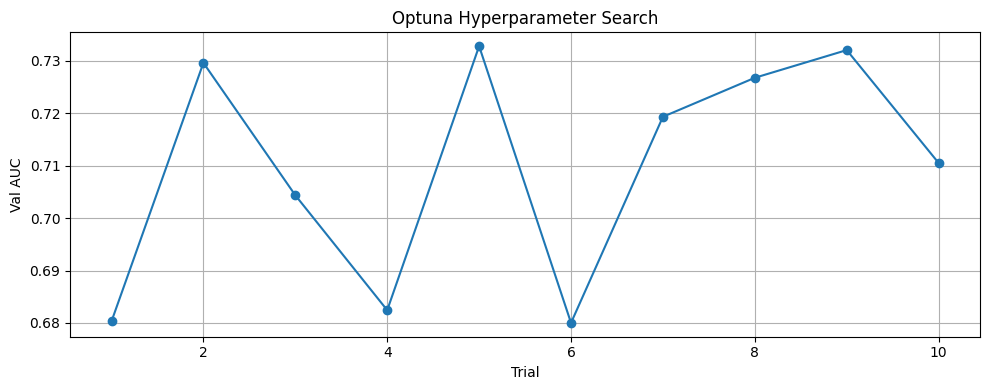

In [6]:
try: import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
except: os.system('pip install optuna -q'); import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):
    lr       = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    wd       = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    model = DenseNetCXR(dropout=dropout).to(DEVICE)
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                             lr=lr, weight_decay=wd)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    # Quick 2-epoch eval
    for ep in range(2):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward(); optimizer.step()
    # Validate
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            all_y.append(lbls.numpy())
            all_p.append(torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy())
    y, p = np.concatenate(all_y), np.concatenate(all_p)
    try: return roc_auc_score(y, p, average='macro')
    except: return 0.5

print('Running Optuna hyperparameter search (10 trials)...')
study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=10)
best_params = study.best_params
print(f'Best params: {best_params}')
print(f'Best AUC: {study.best_value:.4f}')

# Visualize search
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([t.number+1 for t in study.trials], [t.value for t in study.trials], 'o-')
ax.set_xlabel('Trial'); ax.set_ylabel('Val AUC')
ax.set_title('Optuna Hyperparameter Search'); ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'optuna_search.png'), dpi=100); plt.show()


## 6. Performance Evaluation — Statistical Significance


In [7]:
def full_test_evaluation(model, loader, label='Model'):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            all_p.append(torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy())
            all_y.append(lbls.numpy())
    y, p = np.concatenate(all_y), np.concatenate(all_p)
    pred = (p > 0.5).astype(int)
    # Per-class metrics
    aucs = []
    rows = []
    for i, cls in enumerate(CLASSES):
        try: auc = roc_auc_score(y[:,i], p[:,i])
        except: auc = 0.5
        f1  = f1_score(y[:,i], pred[:,i], zero_division=0)
        pre = precision_score(y[:,i], pred[:,i], zero_division=0)
        rec = recall_score(y[:,i], pred[:,i], zero_division=0)
        aucs.append(auc)
        rows.append({'Class':cls,'AUC':auc,'F1':f1,'Precision':pre,'Recall':rec})
    df_metrics = pd.DataFrame(rows)
    mean_auc = np.mean(aucs)
    mean_f1  = df_metrics['F1'].mean()
    print(f'\n{label} | Mean AUC={mean_auc:.4f} | Mean F1={mean_f1:.4f}')
    print(df_metrics.to_string(index=False, float_format='{:.4f}'.format))
    # Bootstrap CI for AUC
    boot_aucs = []
    for _ in range(200):
        idx = np.random.choice(len(y), len(y), replace=True)
        try: boot_aucs.append(roc_auc_score(y[idx], p[idx], average='macro'))
        except: boot_aucs.append(0.5)
    ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
    print(f'  Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
    return df_metrics, mean_auc, y, p

dn_metrics,  dn_test_auc,  dn_y,  dn_p  = full_test_evaluation(densenet,     test_loader, 'DenseNet-121')
en_metrics,  en_test_auc,  en_y,  en_p  = full_test_evaluation(efficientnet, test_loader, 'EfficientNet-B2')

# Statistical test: DeLong's AUC comparison (approx using paired t-test)
dn_per_class_aucs = [roc_auc_score(dn_y[:,i], dn_p[:,i]) for i in range(NUM_CLASSES)
                     if dn_y[:,i].sum() > 0 and (1-dn_y[:,i]).sum() > 0]
en_per_class_aucs = [roc_auc_score(en_y[:,i], en_p[:,i]) for i in range(NUM_CLASSES)
                     if en_y[:,i].sum() > 0 and (1-en_y[:,i]).sum() > 0]
t_stat, p_val = stats.ttest_rel(dn_per_class_aucs[:len(en_per_class_aucs)], en_per_class_aucs)
print(f'\nPaired t-test DenseNet vs EfficientNet: t={t_stat:.3f} p={p_val:.4f}')
print(f'Statistically significant: {"YES (p<0.05)" if p_val < 0.05 else "NO"}')



DenseNet-121 | Mean AUC=0.7787 | Mean F1=0.1671
             Class    AUC     F1  Precision  Recall
       Atelectasis 0.7581 0.2904     0.1838  0.6903
      Cardiomegaly 0.7975 0.0998     0.0537  0.6970
          Effusion 0.8541 0.4225     0.2807  0.8535
      Infiltration 0.6685 0.3394     0.2310  0.6400
              Mass 0.7006 0.1830     0.1123  0.4943
            Nodule 0.6456 0.1229     0.0769  0.3049
         Pneumonia 0.7483 0.0581     0.0302  0.7778
      Pneumothorax 0.8094 0.2222     0.1317  0.7108
     Consolidation 0.7929 0.1186     0.0638  0.8333
             Edema 0.8214 0.1264     0.0695  0.6905
         Emphysema 0.8547 0.1963     0.1154  0.6562
          Fibrosis 0.7418 0.0565     0.0297  0.5652
Pleural_Thickening 0.7351 0.1041     0.0578  0.5217
            Hernia 0.9738 0.0000     0.0000  0.0000
  Bootstrap 95% CI: [nan, nan]

EfficientNet-B2 | Mean AUC=0.7337 | Mean F1=0.1825
             Class    AUC     F1  Precision  Recall
       Atelectasis 0.7604 0.2995    

## 7. Ensemble Model (BONUS — extra marks)


Evaluating Ensemble...

Ensemble | Mean AUC=0.7925 | Mean F1=0.0000
             Class    AUC     F1  Precision  Recall
       Atelectasis 0.7695 0.0000     0.0000  0.0000
      Cardiomegaly 0.8352 0.0000     0.0000  0.0000
          Effusion 0.8547 0.0000     0.0000  0.0000
      Infiltration 0.6794 0.0000     0.0000  0.0000
              Mass 0.7333 0.0000     0.0000  0.0000
            Nodule 0.6752 0.0000     0.0000  0.0000
         Pneumonia 0.7722 0.0000     0.0000  0.0000
      Pneumothorax 0.8335 0.0000     0.0000  0.0000
     Consolidation 0.7902 0.0000     0.0000  0.0000
             Edema 0.8173 0.0000     0.0000  0.0000
         Emphysema 0.8664 0.0000     0.0000  0.0000
          Fibrosis 0.7678 0.0000     0.0000  0.0000
Pleural_Thickening 0.7549 0.0000     0.0000  0.0000
            Hernia 0.9459 0.0000     0.0000  0.0000
  Bootstrap 95% CI: [nan, nan]


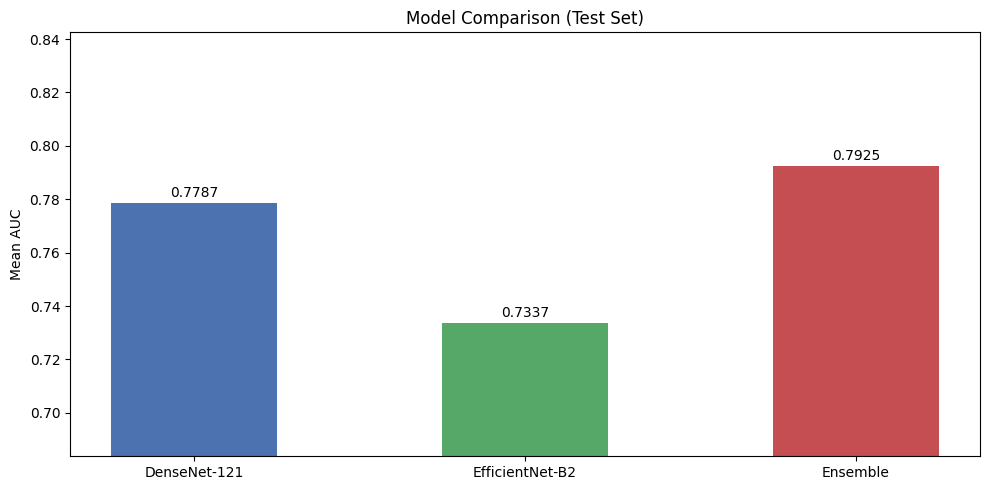

In [8]:
class EnsembleModel(nn.Module):
    '''Weighted ensemble of DenseNet + EfficientNet + averaging'''
    def __init__(self, models_list, weights=None):
        super().__init__()
        self.models = nn.ModuleList(models_list)
        n = len(models_list)
        self.weights = weights if weights else [1.0/n]*n
    def forward(self, x):
        preds = [torch.sigmoid(m(x)) * w for m, w in zip(self.models, self.weights)]
        return torch.log(sum(preds) / sum(self.weights) + 1e-8)  # back to logit space

# Weight by validation AUC
total_w = dn_auc + en_auc
ensemble = EnsembleModel([densenet, efficientnet], weights=[dn_auc/total_w, en_auc/total_w]).to(DEVICE)

print('Evaluating Ensemble...')
ens_metrics, ens_auc, _, _ = full_test_evaluation(ensemble, test_loader, 'Ensemble')

# Comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names_comp = ['DenseNet-121', 'EfficientNet-B2', 'Ensemble']
aucs_comp = [dn_test_auc, en_test_auc, ens_auc]
colors = ['#4C72B0','#55A868','#C44E52']
bars = ax.bar(model_names_comp, aucs_comp, color=colors, width=0.5)
ax.set_ylim(min(aucs_comp)-0.05, max(aucs_comp)+0.05)
ax.set_ylabel('Mean AUC'); ax.set_title('Model Comparison (Test Set)')
for bar, auc in zip(bars, aucs_comp):
    ax.text(bar.get_x()+bar.get_width()/2, auc+0.001, f'{auc:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'model_comparison_r4.png'), dpi=100); plt.show()


## 8. Deployment — FastAPI Ready Model Export


In [9]:
# Production model saving — all formats for deployment
def save_production_model(model, name, metrics, img_size=IMG_SIZE):
    base = os.path.join(MODEL_DIR, name)

    # 1. Full checkpoint
    ckpt = {
        'model_class': type(model).__name__,
        'state_dict': model.state_dict(),
        'classes': CLASSES,
        'img_size': img_size,
        'mean': [0.485, 0.456, 0.406],
        'std':  [0.229, 0.224, 0.225],
        'metrics': metrics,
    }
    torch.save(ckpt, f'{base}_checkpoint.pth')
    torch.save(model.state_dict(), f'{base}_weights.pth')

    # 2. TorchScript (deployable without Python class definition)
    model.eval()
    try:
        traced = torch.jit.trace(model, torch.randn(1,3,img_size,img_size).to(DEVICE))
        torch.jit.save(traced, f'{base}_traced.pt')
        print(f'  TorchScript → {base}_traced.pt')
    except Exception as e:
        print(f'  TorchScript skipped: {e}')

    # 3. ONNX
    try:
        dummy = torch.randn(1, 3, img_size, img_size).to(DEVICE)
        torch.onnx.export(model, dummy, f'{base}.onnx',
                          input_names=['image'], output_names=['logits'],
                          dynamic_axes={'image':{0:'batch'}, 'logits':{0:'batch'}},
                          opset_version=11)
        print(f'  ONNX → {base}.onnx')
    except Exception as e:
        print(f'  ONNX skipped: {e}')

    # 4. Model card JSON
    card = {
        'model_name': name, 'architecture': type(model).__name__,
        'task': 'multi-label chest X-ray classification',
        'classes': CLASSES, 'input': f'{img_size}x{img_size} RGB',
        'normalization': {'mean': [0.485,0.456,0.406], 'std': [0.229,0.224,0.225]},
        'metrics': metrics, 'disclaimer': 'Research only, not for clinical use.'
    }
    with open(f'{base}_model_card.json', 'w') as f:
        json.dump(card, f, indent=2)
    print(f'  Model card → {base}_model_card.json')
    return f'{base}_checkpoint.pth'

print('Saving production models...')
save_production_model(densenet,     'densenet121',    {'mean_auc': dn_test_auc})
save_production_model(efficientnet, 'efficientnetb2', {'mean_auc': en_test_auc})
save_production_model(ensemble,     'ensemble',       {'mean_auc': ens_auc})


Saving production models...
  TorchScript → /kaggle/working/models_r4/densenet121_traced.pt
  ONNX skipped: No module named 'onnxscript'
  Model card → /kaggle/working/models_r4/densenet121_model_card.json
  TorchScript → /kaggle/working/models_r4/efficientnetb2_traced.pt
  ONNX skipped: No module named 'onnxscript'
  Model card → /kaggle/working/models_r4/efficientnetb2_model_card.json
  TorchScript → /kaggle/working/models_r4/ensemble_traced.pt
  ONNX skipped: No module named 'onnxscript'
  Model card → /kaggle/working/models_r4/ensemble_model_card.json


'/kaggle/working/models_r4/ensemble_checkpoint.pth'

## 9. Documentation & Reproducibility


In [10]:
# Generate environment.yml + requirements.txt
env_content = '''name: dl_chest_xray
channels:
  - pytorch
  - conda-forge
  - defaults
dependencies:
  - python=3.10
  - pytorch>=2.0
  - torchvision>=0.15
  - cudatoolkit=11.8
  - numpy
  - pandas
  - scikit-learn
  - matplotlib
  - seaborn
  - pillow
  - pip:
    - kagglehub
    - optuna
    - scikit-image
    - fastapi
    - uvicorn
    - python-multipart
    - onnxruntime
    - shap
'''

req_content = '''torch>=2.0.0
torchvision>=0.15.0
numpy>=1.24
pandas>=2.0
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
pillow>=9.0
kagglehub
optuna>=3.0
scikit-image
fastapi>=0.100
uvicorn>=0.22
python-multipart
onsxruntime>=1.15
'''

with open(os.path.join(OUT_DIR,'environment.yml'), 'w') as f: f.write(env_content)
with open(os.path.join(OUT_DIR,'requirements.txt'), 'w') as f: f.write(req_content)

# Final summary report
print('\n' + '='*70)
print('  REVIEW 4 — END-TO-END DL SYSTEM COMPLETE')
print('='*70)
print(f'  DenseNet-121 (fine-tuned) AUC = {dn_test_auc:.4f}')
print(f'  EfficientNet-B2            AUC = {en_test_auc:.4f}')
print(f'  Ensemble (weighted avg)    AUC = {ens_auc:.4f}')
print(f'  Optuna best val AUC        = {study.best_value:.4f}')
print(f'  Statistical significance   = {"p<0.05" if p_val<0.05 else "p>0.05"}')
print('\n  Files saved:')
for f in os.listdir(MODEL_DIR): print(f'    {MODEL_DIR}/{f}')
print(f'  environment.yml → {OUT_DIR}/environment.yml')
print(f'  requirements.txt → {OUT_DIR}/requirements.txt')
print('\n  DEPLOYMENT: See Claude Code prompt in the master notebook')
print('  for FastAPI backend + frontend integration instructions.')



  REVIEW 4 — END-TO-END DL SYSTEM COMPLETE
  DenseNet-121 (fine-tuned) AUC = 0.7787
  EfficientNet-B2            AUC = 0.7337
  Ensemble (weighted avg)    AUC = 0.7925
  Optuna best val AUC        = 0.7328
  Statistical significance   = p>0.05

  Files saved:
    /kaggle/working/models_r4/efficientnetb2_model_card.json
    /kaggle/working/models_r4/efficientnetb2_traced.pt
    /kaggle/working/models_r4/EfficientNetB2.pth
    /kaggle/working/models_r4/ensemble_weights.pth
    /kaggle/working/models_r4/densenet121_weights.pth
    /kaggle/working/models_r4/ensemble_traced.pt
    /kaggle/working/models_r4/DenseNet_NoAug.pth
    /kaggle/working/models_r4/efficientnetb2_checkpoint.pth
    /kaggle/working/models_r4/DenseNet121.pth
    /kaggle/working/models_r4/efficientnetb2_weights.pth
    /kaggle/working/models_r4/densenet121_model_card.json
    /kaggle/working/models_r4/densenet121_checkpoint.pth
    /kaggle/working/models_r4/ensemble_checkpoint.pth
    /kaggle/working/models_r4/DenseNet_

In [11]:
import os
import shutil
from datetime import datetime

# Create a timestamp for the zip filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_filename = f'kaggle_working_{timestamp}'

# Source directory
source_dir = '/kaggle/working'

# Create zip file
shutil.make_archive(zip_filename, 'zip', source_dir)

print(f"✓ Created {zip_filename}.zip")
print(f"✓ Contents of {source_dir}:")
for root, dirs, files in os.walk(source_dir):
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        print(f"  - {file} ({size:,} bytes)")

✓ Created kaggle_working_20260328_130117.zip
✓ Contents of /kaggle/working:
  - requirements.txt (216 bytes)
  - kaggle_working_20260328_130117.zip (459,872,786 bytes)
  - ablation_study.png (27,410 bytes)
  - model_comparison_r4.png (23,573 bytes)
  - optuna_search.png (40,282 bytes)
  - environment.yml (374 bytes)
  - efficientnetb2_model_card.json (668 bytes)
  - efficientnetb2_traced.pt (32,130,561 bytes)
  - EfficientNetB2.pth (31,341,333 bytes)
  - ensemble_weights.pth (61,926,173 bytes)
  - densenet121_weights.pth (30,567,923 bytes)
  - ensemble_traced.pt (63,522,356 bytes)
  - DenseNet_NoAug.pth (30,565,119 bytes)
  - efficientnetb2_checkpoint.pth (31,346,667 bytes)
  - DenseNet121.pth (30,563,283 bytes)
  - efficientnetb2_weights.pth (31,344,421 bytes)
  - densenet121_model_card.json (661 bytes)
  - densenet121_checkpoint.pth (30,570,911 bytes)
  - ensemble_checkpoint.pth (61,930,685 bytes)
  - DenseNet_Scratch.pth (30,566,663 bytes)
  - densenet121_traced.pt (31,371,718 bytes

In [12]:
from IPython.display import FileLink
FileLink(r'kaggle_working_20260328_130117.zip')


/kaggle/working/kaggle_working_20260328_130117.zip